<a href="https://colab.research.google.com/github/slr549/Machine-Learning-Course-2026/blob/main/assignments/week-08/2411070095_Raki%20Raihan/Ra.Han_W8_Financial%20Risk-(Classification).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup**

In [30]:
# pip install
!pip install kagglehub

# import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import wandb
import os
from google.colab import drive
from google.colab import data_table
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, average_precision_score, ConfusionMatrixDisplay


# import and install kagglehub
kagglehub.login()

# Download Dataset from Kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Succes Location dataset:", path)

# Inisialisasi W&B
#run = wandb.init(project="Financial Risk", name="End-to-End Machine Learning Challenge", description="assesment Week-8 UTS")

# Request Access to Your Google Drive
drive.mount('/content/drive')

# Request Access to your path folder from Google Drive
# Location Folder Path
folder_path = '/content/drive/MyDrive/MACHINE-LEARNING/UTS_week8'
print(f"Succes Load Folder Path: {folder_path}")

if os.path.exists(folder_path):
  print(f"folder ditemukan(folder_path)")

  os.chdir(folder_path)
  print(f"folder aktif: (folder_path){os.getcw()}")
else:
  print(f"folder tidak ditemukan(folder_path)")
#if not os.path.exists(folder_path):
 #   os.makedirs(folder_path)
  #  print(f"folder dibuat(folder_path)")

print("Setup Complete")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Succes Location dataset: /kaggle/input/creditcardfraud
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Succes Load Folder Path: /content/drive/MyDrive/MACHINE-LEARNING/UTS_week8
folder tidak ditemukan(folder_path)
Setup Complete
Kaggle credentials set.
Kaggle credentials successfully validated.


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Get Dataset(creditcard.csv)**

In [32]:
filename = 'creditcard.csv'
filepath = os.path.join(folder_path, filename)

try:
  df_finance = pd.read_csv('creditcard.csv')
  print(f"Berhasil: File {filename} ditemukan dan berhasil dibaca")

except FileNotFoundError:
  print(f"Info: File {filename} tidak ditemukan di direktori lokal, mengunduh via kagglehub...")

  try:
    # Mengunduh Dataset
    path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

    # Search File Dataset
    full_path = os.path.join(path, filename)

    # Membaca File Dataset
    df_finance = pd.read_csv(full_path)
    print(f"Berhasil: Dataset terunduh dan dibaca dari {full_path}")

  except Exception as e:
    print(f"Gagal: Mengunduh Dataset dari kagglehub gagal: {e}")

except Exception as e:
  print(f"Gagal: membaca File dataset: {e}")

Info: File creditcard.csv tidak ditemukan di direktori lokal, mengunduh via kagglehub...
Using Colab cache for faster access to the 'creditcardfraud' dataset.
Berhasil: Dataset terunduh dan dibaca dari /kaggle/input/creditcardfraud/creditcard.csv


**Data Loading**

In [33]:
# Aktivasion Formatter
data_table.enable_dataframe_formatter()

# Call Head
data_tampil = df_finance.head(100)

# Aktifkan Mode Tabel Interaktif
data_table.DataTable(data_tampil, include_index=False, num_rows_per_page=20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,64.0,-0.658305,0.406791,2.037461,-0.291298,0.147910,-0.350857,0.945373,-0.172560,0.025133,...,-0.156096,-0.238805,0.089877,0.421195,-0.352487,0.074783,-0.094192,-0.092493,54.99,0
96,64.0,0.959602,0.370711,0.888613,2.343244,0.352491,1.365515,-0.277771,0.516053,-0.700929,...,-0.155547,-0.403239,0.356504,-0.696881,-0.198718,-0.220268,0.068546,0.020797,7.55,0
97,67.0,-0.653445,0.160225,1.592256,1.296832,0.997175,-0.343000,0.469937,-0.132470,-0.197794,...,0.038363,0.336449,-0.014883,0.102959,-0.265322,-0.348637,0.011238,-0.049478,19.85,0
98,67.0,-1.494668,0.837241,2.628211,3.145414,-0.609098,0.258495,-0.012189,0.102136,-0.286164,...,-0.140047,0.355044,0.332720,0.718193,-0.219366,0.118927,-0.317486,-0.340783,28.28,0


**Scanning Dataset**

In [34]:
# Cek Tipe Data and Score (Null)
df_finance.info()

# Cek Ringkasan Statistik (Mean, Min, Max, Median)
df_finance.describe()

# Cek Sum Baris and Kolom
print("Jumlah Baris:", df_finance.shape[0])
print("Jumlah Kolom:", df_finance.shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Show Distribusi Class (Fraud vs Normal)**

In [35]:
# Melihat Jumlah Data Per Kategori (0:Normal, 1:Fraud)
print(df_finance['Class'].value_counts())

# Menampilkan dalam persentase
print(df_finance['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


**Create Visualisasi**

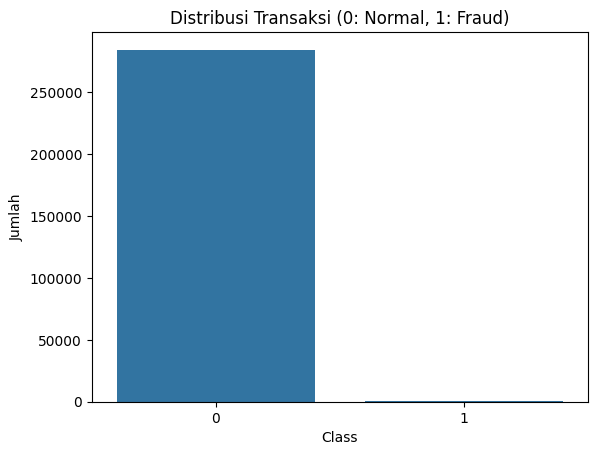

In [36]:
# Plot Distribusi Target
sns.countplot(x='Class', data=df_finance)
plt.title('Distribusi Transaksi (0: Normal, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Jumlah')
plt.show()

**Split fitur**

In [37]:
# Split Fitur (X) dan Target (Y)
x = df_finance.drop('Class', axis=1)
y = df_finance['Class']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)
plt.show()
print("Jumlah Data Training:", len(X_train))
print("Jumlah Data Testing:", len(X_test))
print("Jumlah Data Fraud Training:", sum(y_train==1))
print("Jumlah Data Fraud Testing:", sum(y_test==1))
print("Jumlah Data Normal Training:", sum(y_train==0))
print("Jumlah Data Normal Testing:", sum(y_test==0))
print(y_train.value_counts())
print(y_test.value_counts())
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test.head())
print(df_finance.head())
print(df_finance.tail())
print(df_finance.info())
print(df_finance.describe())
print(df_finance.isnull().sum())
print(df_finance.corr())
print(df_finance.columns)
print(df_finance.shape)
print(df_finance.dtypes)
print("operasional sukses")


Jumlah Data Training: 227845
Jumlah Data Testing: 56962
Jumlah Data Fraud Training: 394
Jumlah Data Fraud Testing: 98
Jumlah Data Normal Training: 227451
Jumlah Data Normal Testing: 56864
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64
(227845, 30)
(56962, 30)
(227845,)
(56962,)
            Time        V1        V2        V3        V4        V5        V6  \
265518  161919.0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  124477.0  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664    41191.0 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  132624.0  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325    59359.0 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782 

**Create SMOTE**

In [38]:
# Terapkan SMOTE data training saja
print(f"Jumlah Data Sebelum SMOTE: {sum(y_train==1)} Fraud")
smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train, y_train)

# Cek Jumlah Data Setelah SMOTE
print("Jumlah Data Setelah SMOTE: {sum(y_train_res==1)} Fraud")
print(Y_train_res.value_counts)

Jumlah Data Sebelum SMOTE: 394 Fraud
Jumlah Data Setelah SMOTE: {sum(y_train_res==1)} Fraud
<bound method IndexOpsMixin.value_counts of 0         0
1         0
2         0
3         0
4         0
         ..
454897    1
454898    1
454899    1
454900    1
454901    1
Name: Class, Length: 454902, dtype: int64>


**Training Model**

In [39]:
model = XGBClassifier()
model.fit(
    X_train_res,
    Y_train_res,
    eval_set=[(X_test, y_test)], # Memantau performa pada data set
    verbose=True # Memunculkan Log output per iterasi
    )

plt.show()
print("operasional sukses")

[0]	validation_0-logloss:0.45716
[1]	validation_0-logloss:0.32227
[2]	validation_0-logloss:0.23587
[3]	validation_0-logloss:0.17746
[4]	validation_0-logloss:0.13661
[5]	validation_0-logloss:0.10750
[6]	validation_0-logloss:0.08604
[7]	validation_0-logloss:0.07001
[8]	validation_0-logloss:0.05774
[9]	validation_0-logloss:0.04887
[10]	validation_0-logloss:0.04211
[11]	validation_0-logloss:0.03685
[12]	validation_0-logloss:0.03288
[13]	validation_0-logloss:0.03001
[14]	validation_0-logloss:0.02729
[15]	validation_0-logloss:0.02507
[16]	validation_0-logloss:0.02338
[17]	validation_0-logloss:0.02180
[18]	validation_0-logloss:0.01994
[19]	validation_0-logloss:0.01773
[20]	validation_0-logloss:0.01651
[21]	validation_0-logloss:0.01574
[22]	validation_0-logloss:0.01431
[23]	validation_0-logloss:0.01352
[24]	validation_0-logloss:0.01267
[25]	validation_0-logloss:0.01178
[26]	validation_0-logloss:0.01136
[27]	validation_0-logloss:0.01066
[28]	validation_0-logloss:0.01005
[29]	validation_0-loglos

**Evaluasi Model**


Evaluasi Model or Klasifikasi

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.85      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962


VISUALISASI HASIL:


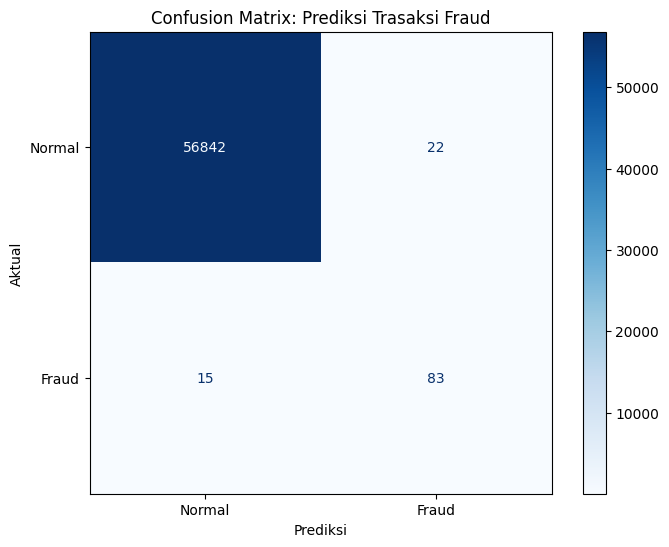

Akurasi: 0.9993504441557529
AUPRC: 0.669748270282246

--- Evaluasi UTS ---
Akurasi Score: 0.9994
AUPRC Score: 0.6697
--------------------
operasional sukses


In [40]:
# Run Prediksi
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # ambil probabilitas kelas 1

# Evaluasi Hitung Matrik
accuracy = accuracy_score(y_test, y_pred)
auprc = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
auprc = average_precision_score(y_test, y_pred)

# Show Statistik
print("\n" + "="*40)
print("Evaluasi Model or Klasifikasi")
print("="*40 + "\n")
print(classification_report(y_test, y_pred))

# Show Grafik Confusion Matrix
print("\nVISUALISASI HASIL:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Prediksi Trasaksi Fraud')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.grid(False)
plt.show()

# Show Akurasi dan AUPRC
print("Akurasi:", accuracy)
print("AUPRC:", auprc)

print("\n--- Evaluasi UTS ---")
print(f"Akurasi Score: {accuracy:.4f}")
print(f"AUPRC Score: {auprc:.4f}")
print("-" * 20)
print("operasional sukses")

**Save to Your Weights & Biases**

In [42]:
# Membuat Tabel di W&B
#table = wandb.Table(dataframe=df_finance)
#wandb.log({'creditcard_dataset': table})
#wandb.log({"auprc": auprc})
drive.flush_and_unmount()